# Rock Paper Scissors 이미지 분류

이 노트북은 Rock Paper Scissors 데이터셋을 사용하여 바위/보/가위 손 모양을 분류하는 모델을 학습합니다.

## 목표
1. 이미지 증강 전후의 모델 성능 비교
2. ROC curve를 사용한 성능 평가
3. 새로운 이미지에 대한 분류 결과 확인


## 1. 라이브러리 임포트 및 설정


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import os
import warnings
warnings.filterwarnings('ignore')

# 시드 설정
tf.random.set_seed(42)
np.random.seed(42)

# GPU 사용 가능 여부 확인
print("TensorFlow 버전:", tf.__version__)
print("GPU 사용 가능:", tf.config.list_physical_devices('GPU'))


TensorFlow 버전: 2.10.0
GPU 사용 가능: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. 데이터 로딩 및 전처리


In [2]:
# 데이터 경로 설정
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "data/rock-paper-scissors/train"
valid_dir = "data/rock-paper-scissors/valid"
test_dir = "data/rock-paper-scissors/test"

# 데이터셋 로딩
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 클래스 이름 확인
class_names = train_ds.class_names
print("클래스 이름:", class_names)
print(f"클래스 수: {len(class_names)}")

# 데이터셋 크기 확인
print(f"훈련 데이터 배치 수: {len(train_ds)}")
print(f"검증 데이터 배치 수: {len(valid_ds)}")
print(f"테스트 데이터 배치 수: {len(test_ds)}")


Found 2520 files belonging to 3 classes.
Found 372 files belonging to 3 classes.
Found 33 files belonging to 3 classes.
클래스 이름: ['paper', 'rock', 'scissors']
클래스 수: 3
훈련 데이터 배치 수: 79
검증 데이터 배치 수: 12
테스트 데이터 배치 수: 2


In [3]:
# 데이터 샘플 확인
for images, labels in train_ds.take(1):
    print(f"이미지 shape: {images.shape}")
    print(f"라벨 shape: {labels.shape}")
    print(f"이미지 데이터 타입: {images.dtype}")
    print(f"이미지 값 범위: {images.numpy().min():.3f} ~ {images.numpy().max():.3f}")
    print(f"첫 10개 라벨: {labels[:10].numpy()}")
    print(f"첫 10개 클래스명: {[class_names[i] for i in labels[:10].numpy()]}")
    break


이미지 shape: (32, 224, 224, 3)
라벨 shape: (32,)
이미지 데이터 타입: <dtype: 'float32'>
이미지 값 범위: 0.062 ~ 255.000
첫 10개 라벨: [2 0 0 0 1 1 0 1 1 1]
첫 10개 클래스명: ['scissors', 'paper', 'paper', 'paper', 'rock', 'rock', 'paper', 'rock', 'rock', 'rock']


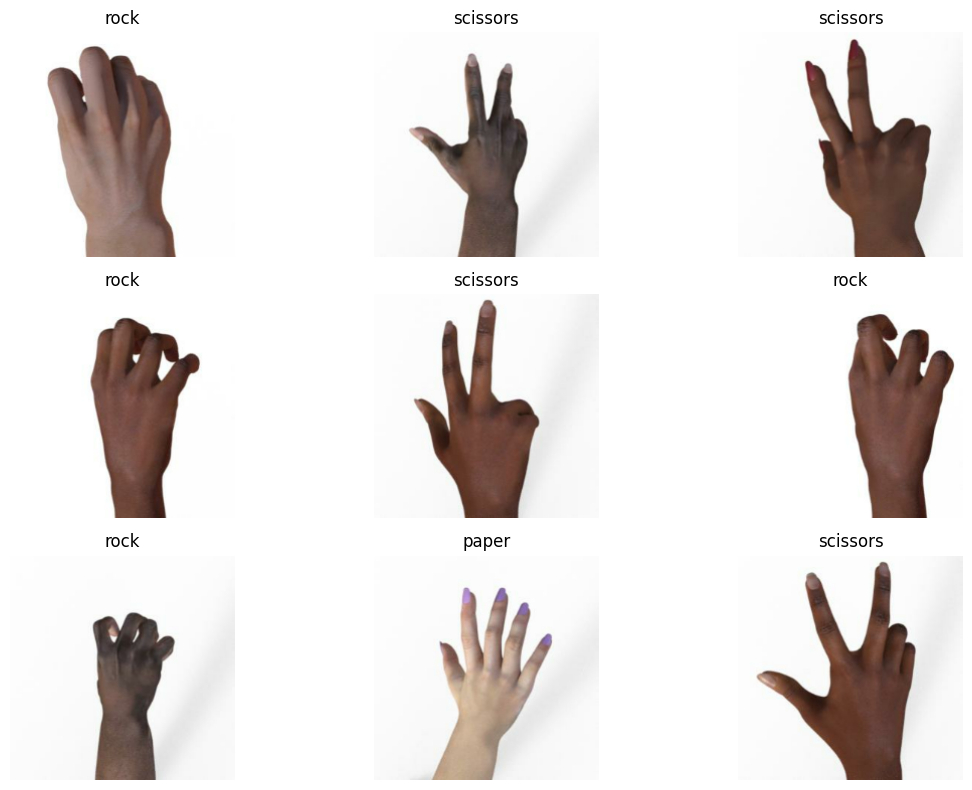

In [4]:
# 데이터 시각화
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(f"{class_names[labels[i]]}")
        plt.axis("off")
    break
plt.tight_layout()
plt.show()


## 3. 데이터 전처리 및 정규화


In [5]:
# 데이터 정규화 (0-1 범위로)
def normalize_data(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# 데이터셋에 정규화 적용
train_ds = train_ds.map(normalize_data)
valid_ds = valid_ds.map(normalize_data)
test_ds = test_ds.map(normalize_data)

# 성능 최적화
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
valid_ds = valid_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("데이터 전처리 완료")


데이터 전처리 완료


## 4. 기본 CNN 모델 생성 (이미지 증강 없이)


In [6]:
def create_basic_model():
    model = tf.keras.Sequential([
        # 첫 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 두 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 세 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 네 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 분류기
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    
    return model

# 기본 모델 생성
basic_model = create_basic_model()
basic_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("기본 모델 구조:")
basic_model.summary()


기본 모델 구조:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 222, 222, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 dropout (Dropout)           (None, 111, 111, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 batch_normalization_1 (Batc  (None, 109, 109,

In [7]:
# 콜백 설정
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7
    )
]

# 기본 모델 훈련
print("기본 모델 훈련 시작...")
basic_history = basic_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print("기본 모델 훈련 완료")


기본 모델 훈련 시작...
Epoch 1/50
79/79 [==============================] - 25s 149ms/step - loss: 0.3449 - accuracy: 0.8679 - val_loss: 5.0760 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 2/50
79/79 [==============================] - 9s 116ms/step - loss: 0.0503 - accuracy: 0.9841 - val_loss: 13.7189 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 3/50
79/79 [==============================] - 9s 111ms/step - loss: 0.0309 - accuracy: 0.9893 - val_loss: 23.5878 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 4/50
79/79 [==============================] - 9s 110ms/step - loss: 0.0136 - accuracy: 0.9956 - val_loss: 28.6944 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 5/50
79/79 [==============================] - 9s 116ms/step - loss: 0.0277 - accuracy: 0.9893 - val_loss: 27.7282 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 6/50
79/79 [==============================] - 9s 119ms/step - loss: 0.0211 - accuracy: 0.9937 - val_loss: 7.4363 - val_accuracy: 0.4704 - lr: 0.0010
Epoch 7/50
79/79 [==============================] 

## 5. 이미지 증강을 적용한 모델 생성


In [8]:
# 이미지 증강 레이어 정의
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])

def create_augmented_model():
    model = tf.keras.Sequential([
        # 입력 레이어
        tf.keras.layers.Input(shape=(224, 224, 3)),
        
        # 이미지 증강
        data_augmentation,
        
        # 첫 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 두 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 세 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 네 번째 컨볼루션 블록
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),
        
        # 분류기
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(3, activation='softmax')
    ])
    
    return model

# 증강 모델 생성
augmented_model = create_augmented_model()
augmented_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("증강 모델 구조:")
augmented_model.summary()


증강 모델 구조:
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 conv2d_4 (Conv2D)           (None, 222, 222, 32)      896       
                                                                 
 batch_normalization_5 (Batc  (None, 222, 222, 32)     128       
 hNormalization)                                                 
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 111, 111, 32)     0         
 2D)                                                             
                                                                 
 dropout_5 (Dropout)         (None, 111, 111, 32)      0         
                                                                 
 conv2d_5 (Conv2D)           (None, 109, 109

In [9]:
# 증강 모델 훈련
print("증강 모델 훈련 시작...")
augmented_history = augmented_model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=50,
    callbacks=callbacks,
    verbose=1
)

print("증강 모델 훈련 완료")


증강 모델 훈련 시작...
Epoch 1/50
79/79 [==============================] - 42s 436ms/step - loss: 1.6188 - accuracy: 0.3210 - val_loss: 1.1146 - val_accuracy: 0.3656 - lr: 0.0010
Epoch 2/50
79/79 [==============================] - 36s 454ms/step - loss: 1.5148 - accuracy: 0.3202 - val_loss: 1.1928 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 3/50
79/79 [==============================] - 39s 496ms/step - loss: 1.4173 - accuracy: 0.3294 - val_loss: 1.2657 - val_accuracy: 0.3333 - lr: 0.0010
Epoch 4/50
77/79 [============================>.] - ETA: 1s - loss: 1.3627 - accuracy: 0.3259

KeyboardInterrupt: 

## 6. 모델 성능 비교


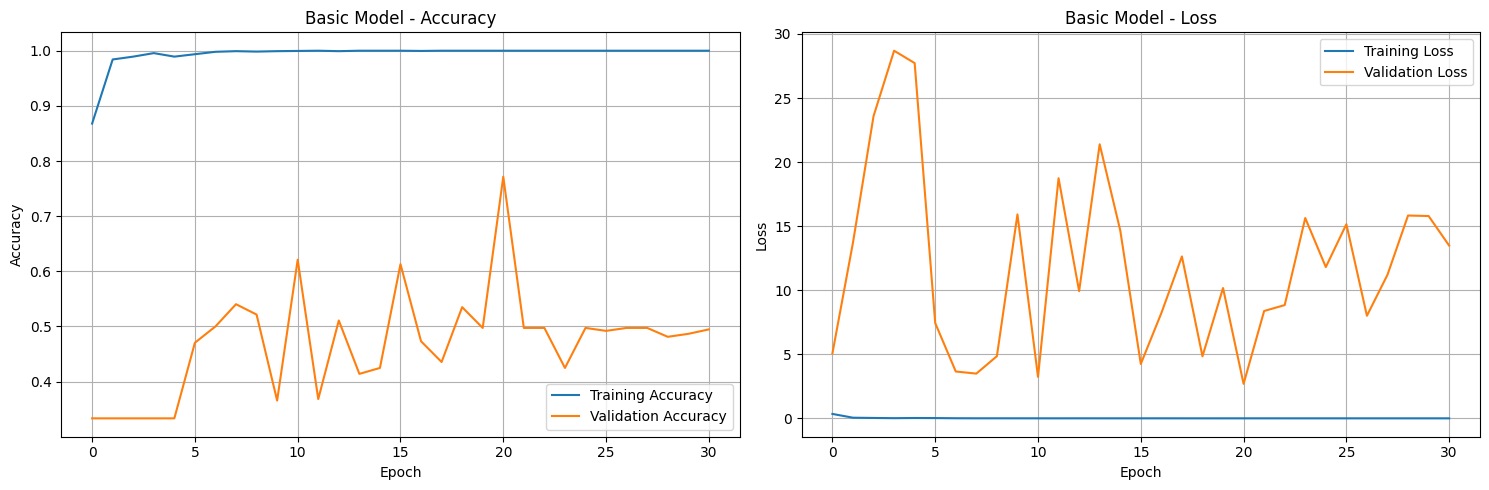

NameError: name 'augmented_history' is not defined

In [10]:
# 훈련 히스토리 시각화
def plot_training_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # 정확도
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    
    # 손실
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# 기본 모델 히스토리
plot_training_history(basic_history, 'Basic Model')

# 증강 모델 히스토리
plot_training_history(augmented_history, 'Augmented Model')


In [11]:
# 테스트 데이터로 평가
print("=== 모델 성능 평가 ===")

# 기본 모델 평가
basic_test_loss, basic_test_acc = basic_model.evaluate(test_ds, verbose=0)
print(f"기본 모델 - 테스트 정확도: {basic_test_acc:.4f}, 테스트 손실: {basic_test_loss:.4f}")

# 증강 모델 평가
augmented_test_loss, augmented_test_acc = augmented_model.evaluate(test_ds, verbose=0)
print(f"증강 모델 - 테스트 정확도: {augmented_test_acc:.4f}, 테스트 손실: {augmented_test_loss:.4f}")

# 성능 개선 확인
improvement = augmented_test_acc - basic_test_acc
print(f"\n성능 개선: {improvement:.4f} ({improvement*100:.2f}%)")


=== 모델 성능 평가 ===
기본 모델 - 테스트 정확도: 0.5758, 테스트 손실: 4.6733
증강 모델 - 테스트 정확도: 0.3333, 테스트 손실: 1.1221

성능 개선: -0.2424 (-24.24%)


## 7. ROC Curve 및 분류 리포트


In [12]:
# 테스트 데이터에서 예측 수행
def get_predictions(model, dataset):
    y_true = []
    y_pred_proba = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred_proba.extend(predictions)
    
    return np.array(y_true), np.array(y_pred_proba)

# 예측 수행
basic_y_true, basic_y_pred_proba = get_predictions(basic_model, test_ds)
augmented_y_true, augmented_y_pred_proba = get_predictions(augmented_model, test_ds)

print(f"기본 모델 예측 완료: {basic_y_pred_proba.shape}")
print(f"증강 모델 예측 완료: {augmented_y_pred_proba.shape}")


기본 모델 예측 완료: (33, 3)
증강 모델 예측 완료: (33, 3)


=== 기본 모델 ROC Curve ===


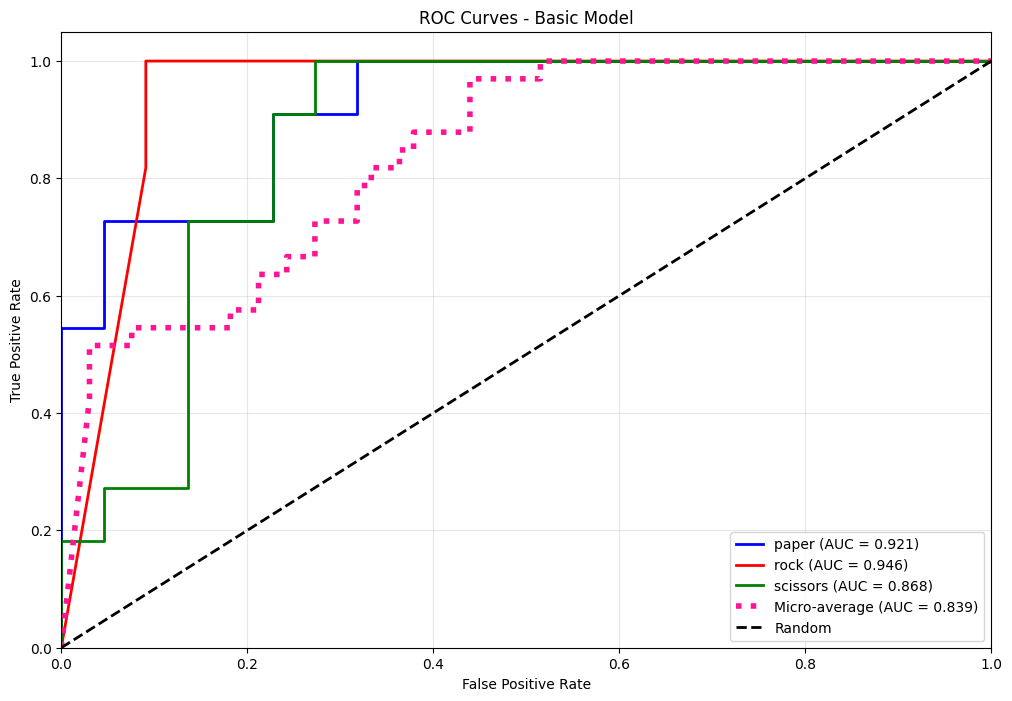

=== 증강 모델 ROC Curve ===


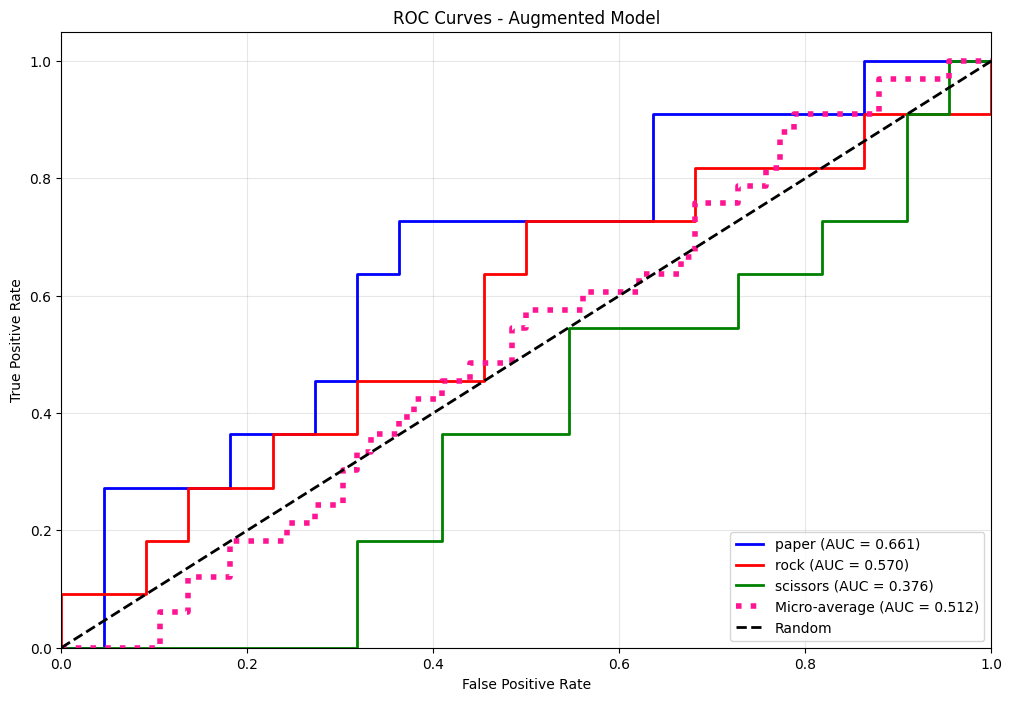

In [13]:
# ROC Curve 그리기
def plot_roc_curves(y_true, y_pred_proba, class_names, title):
    # 라벨을 원-핫 인코딩
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    
    # 각 클래스별 ROC curve 계산
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # 마이크로 평균 ROC curve
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # 플롯 그리기
    plt.figure(figsize=(12, 8))
    
    # 각 클래스별 ROC curve
    colors = ['blue', 'red', 'green']
    for i, color in zip(range(len(class_names)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{class_names[i]} (AUC = {roc_auc[i]:.3f})')
    
    # 마이크로 평균 ROC curve
    plt.plot(fpr["micro"], tpr["micro"], color='deeppink', linestyle=':', linewidth=4,
            label=f'Micro-average (AUC = {roc_auc["micro"]:.3f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves - {title}')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return roc_auc

# 기본 모델 ROC curve
print("=== 기본 모델 ROC Curve ===")
basic_auc = plot_roc_curves(basic_y_true, basic_y_pred_proba, class_names, "Basic Model")

# 증강 모델 ROC curve
print("=== 증강 모델 ROC Curve ===")
augmented_auc = plot_roc_curves(augmented_y_true, augmented_y_pred_proba, class_names, "Augmented Model")



=== Basic Model 분류 리포트 ===
              precision    recall  f1-score   support

       paper       0.88      0.64      0.74        11
        rock       0.46      1.00      0.63        11
    scissors       1.00      0.09      0.17        11

    accuracy                           0.58        33
   macro avg       0.78      0.58      0.51        33
weighted avg       0.78      0.58      0.51        33



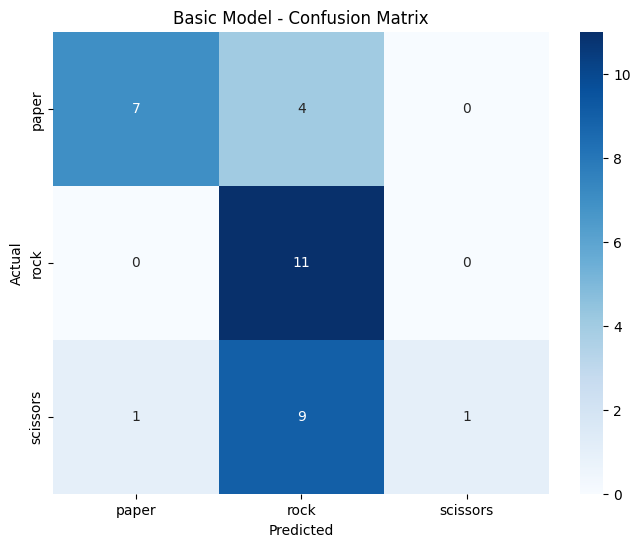


=== Augmented Model 분류 리포트 ===
              precision    recall  f1-score   support

       paper       0.00      0.00      0.00        11
        rock       0.00      0.00      0.00        11
    scissors       0.33      1.00      0.50        11

    accuracy                           0.33        33
   macro avg       0.11      0.33      0.17        33
weighted avg       0.11      0.33      0.17        33



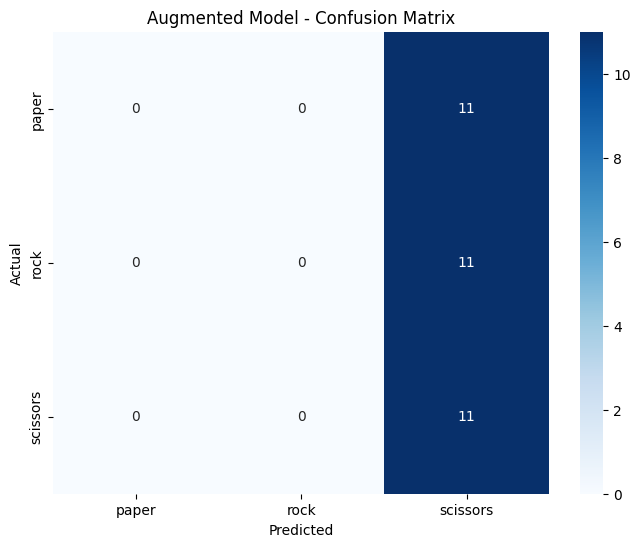

In [14]:
# 분류 리포트
def print_classification_report(y_true, y_pred_proba, class_names, title):
    y_pred = np.argmax(y_pred_proba, axis=1)
    
    print(f"\n=== {title} 분류 리포트 ===")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    # 혼동 행렬
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# 기본 모델 분류 리포트
print_classification_report(basic_y_true, basic_y_pred_proba, class_names, "Basic Model")

# 증강 모델 분류 리포트
print_classification_report(augmented_y_true, augmented_y_pred_proba, class_names, "Augmented Model")


## 8. 새로운 이미지에 대한 분류 결과 확인


In [ ]:
# 새로운 이미지 분류 함수
def predict_new_image(model, image_path, class_names):
    # 이미지 로드 및 전처리
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # 배치 차원 추가
    img_array = img_array / 255.0  # 정규화
    
    # 예측
    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]
    
    return predicted_class, confidence, predictions[0]

# 테스트 이미지들로 예측 테스트
def test_predictions_on_sample_images():
    # 각 클래스별로 몇 개의 테스트 이미지 선택
    test_images = []
    for class_name in class_names:
        class_dir = f"data/rock-paper-scissors/test/{class_name}"
        if os.path.exists(class_dir):
            images = os.listdir(class_dir)[:3]  # 각 클래스에서 3개씩
            for img in images:
                test_images.append((f"{class_dir}/{img}", class_name))
    
    # 예측 수행 및 시각화
    fig, axes = plt.subplots(3, 6, figsize=(18, 9))
    axes = axes.ravel()
    
    for i, (img_path, true_class) in enumerate(test_images[:18]):  # 최대 18개
        # 기본 모델 예측
        basic_pred, basic_conf, basic_probs = predict_new_image(basic_model, img_path, class_names)
        
        # 증강 모델 예측
        aug_pred, aug_conf, aug_probs = predict_new_image(augmented_model, img_path, class_names)
        
        # 이미지 표시
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_class}\nBasic: {class_names[basic_pred]} ({basic_conf:.2f})\nAug: {class_names[aug_pred]} ({aug_conf:.2f})")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# 샘플 이미지들로 테스트
test_predictions_on_sample_images()


## 9. 모델 저장


In [ ]:
# 모델 저장
basic_model.save('rock_paper_scissors_basic_model.keras')
augmented_model.save('rock_paper_scissors_augmented_model.keras')

print("모델 저장 완료:")
print("- rock_paper_scissors_basic_model.keras")
print("- rock_paper_scissors_augmented_model.keras")


## 10. 결과 요약


In [15]:
print("=== 최종 결과 요약 ===")
print(f"\n1. 기본 모델 성능:")
print(f"   - 테스트 정확도: {basic_test_acc:.4f}")
print(f"   - 테스트 손실: {basic_test_loss:.4f}")
print(f"   - 마이크로 평균 AUC: {basic_auc['micro']:.4f}")

print(f"\n2. 증강 모델 성능:")
print(f"   - 테스트 정확도: {augmented_test_acc:.4f}")
print(f"   - 테스트 손실: {augmented_test_loss:.4f}")
print(f"   - 마이크로 평균 AUC: {augmented_auc['micro']:.4f}")

print(f"\n3. 성능 개선:")
print(f"   - 정확도 개선: {improvement:.4f} ({improvement*100:.2f}%)")
print(f"   - AUC 개선: {augmented_auc['micro'] - basic_auc['micro']:.4f}")

print(f"\n4. 클래스별 성능 (증강 모델):")
for i, class_name in enumerate(class_names):
    print(f"   - {class_name}: AUC = {augmented_auc[i]:.4f}")

print("\n=== 분석 완료 ===")


=== 최종 결과 요약 ===

1. 기본 모델 성능:
   - 테스트 정확도: 0.5758
   - 테스트 손실: 4.6733
   - 마이크로 평균 AUC: 0.8388

2. 증강 모델 성능:
   - 테스트 정확도: 0.3333
   - 테스트 손실: 1.1221
   - 마이크로 평균 AUC: 0.5119

3. 성능 개선:
   - 정확도 개선: -0.2424 (-24.24%)
   - AUC 개선: -0.3269

4. 클래스별 성능 (증강 모델):
   - paper: AUC = 0.6612
   - rock: AUC = 0.5702
   - scissors: AUC = 0.3760

=== 분석 완료 ===
